# Project NLP | Business Case: Automated Customer Reviews

### This project seeks to build an advanced product review system leveraging Natural Language Processing (NLP) models to aggregate and analyze customer feedback from multiple sources. Core objectives include review classification, product category clustering, and the application of generative AI to produce concise recommendation articles based on user reviews

# 1.Import necessary libary

In [1]:
!pip install transformers

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import torch

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

# 2. Download Dataset


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install kaggle

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"wejdanmjd","key":"0155c4d3d2d15b5e0986d90213eb997d"}'}

In [5]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content'

In [6]:
!kaggle datasets download -d datafiniti/consumer-reviews-of-amazon-products -p /content

Dataset URL: https://www.kaggle.com/datasets/datafiniti/consumer-reviews-of-amazon-products
License(s): CC-BY-NC-SA-4.0


In [7]:
!unzip /content/consumer-reviews-of-amazon-products.zip -d /content

Archive:  /content/consumer-reviews-of-amazon-products.zip
  inflating: /content/1429_1.csv     
  inflating: /content/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv  
  inflating: /content/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv  


In [8]:
import pandas as pd

# Load the May19 file
df1 = pd.read_csv("Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv")

# Load the general file (could contain extra data)
df2 = pd.read_csv("Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv")

# Merge both dataframes
df_merged = pd.concat([df1, df2], ignore_index=True)

# - Exploratory Data Analysis -


In [ ]:
print(df_merged.columns)

Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs',
       'reviews.dateAdded'],
      dtype='object')


In [ ]:
# check label distribution
rating_counts = df_merged['reviews.rating'].value_counts().sort_index()


# display the number of reviews per rating
print(rating_counts)

reviews.rating
1     1028
2      670
3     1403
4     6856
5    23375
Name: count, dtype: int64


In [ ]:
print(df_merged.shape)

(33332, 25)


<ipython-input-13-bf34f1ef86bc>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="Blues_d")


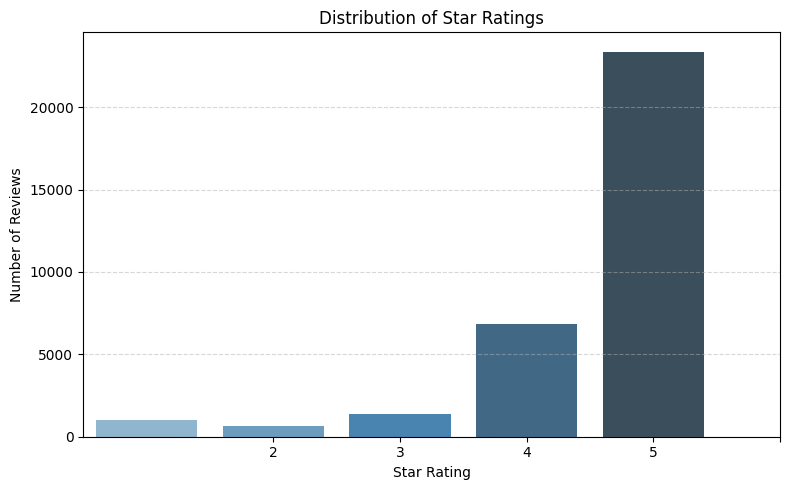

In [ ]:
import matplotlib.pyplot as plt

rating_counts = df_merged['reviews.rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="Blues_d")

#plot Distribution
plt.title("Distribution of Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.xticks(ticks=[1, 2, 3, 4, 5])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33332 entries, 0 to 33331
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   33332 non-null  object 
 1   dateAdded            33332 non-null  object 
 2   dateUpdated          33332 non-null  object 
 3   name                 33332 non-null  object 
 4   asins                33332 non-null  object 
 5   brand                33332 non-null  object 
 6   categories           33332 non-null  object 
 7   primaryCategories    33332 non-null  object 
 8   imageURLs            33332 non-null  object 
 9   keys                 33332 non-null  object 
 10  manufacturer         33332 non-null  object 
 11  manufacturerNumber   33332 non-null  object 
 12  reviews.date         33332 non-null  object 
 13  reviews.dateSeen     33332 non-null  object 
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.doRecommend  21086 non-null 

In [ ]:
missing_values = df_merged.isnull().sum()
print(missing_values[missing_values > 0])

reviews.didPurchase    33323
reviews.doRecommend    12246
reviews.id             33262
reviews.numHelpful     12217
reviews.title             13
reviews.username           6
reviews.dateAdded      32280
dtype: int64


# - Clean the Data -

In [9]:
# Step 1: Drop columns that are not needed or contain too many missing values
df_clean = df_merged.drop(columns=['reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.dateAdded'])

# Step 2: Handle missing values in 'reviews.username' and 'reviews.title' by replacing with 'Unknown'
df_clean['reviews.username'].fillna('Unknown', inplace=True)
df_clean['reviews.title'].fillna('Unknown', inplace=True)

# Display the cleaned dataframe
df_clean.head()

<ipython-input-9-ceb4e7b16da3>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['reviews.username'].fillna('Unknown', inplace=True)
<ipython-input-9-ceb4e7b16da3>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,manufacturer,manufacturerNumber,reviews.date,reviews.dateSeen,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",AmazonBasics,HL-002619,2017-03-02T00:00:00.000Z,2017-08-28T00:00:00Z,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",AmazonBasics,HL-002619,2016-08-31T00:00:00.000Z,2017-08-28T00:00:00Z,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",AmazonBasics,HL-002619,2016-12-06T00:00:00.000Z,2017-08-28T00:00:00Z,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",AmazonBasics,HL-002619,2016-03-28T00:00:00.000Z,2017-08-28T00:00:00Z,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",AmazonBasics,HL-002619,2017-04-22T00:00:00.000Z,2017-08-28T00:00:00Z,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


In [10]:
# Verify the shape of the cleaned DataFrame
print("Data shape after cleaning:", df_clean.shape)

Data shape after cleaning: (33332, 20)


In [10]:
# Check for any remaining missing values
missing_values_cleaned = df_clean.isnull().sum()
print("\nMissing values in the cleaned DataFrame:")
print(missing_values_cleaned)


Missing values in the cleaned DataFrame:
id                    0
dateAdded             0
dateUpdated           0
name                  0
asins                 0
brand                 0
categories            0
primaryCategories     0
imageURLs             0
keys                  0
manufacturer          0
manufacturerNumber    0
reviews.date          0
reviews.dateSeen      0
reviews.rating        0
reviews.sourceURLs    0
reviews.text          0
reviews.title         0
reviews.username      0
sourceURLs            0
dtype: int64


# Task 0 : Adding a "Sentiment Class" column based on "Star Rating"

In [11]:
# Adding a "Sentiment Class" column based on "Star Rating"
df_clean['Sentiment Class'] = df_clean['reviews.rating'].apply(
    lambda x: 'Negative' if x <= 2 else ('Neutral' if x == 3 else 'Positive')
)

In [12]:
# Count the number of unique values in the "Sentiment Class" column
sentiment_counts = df_clean['Sentiment Class'].value_counts()

# Print the results
print(sentiment_counts)

Sentiment Class
Positive    30231
Negative     1698
Neutral      1403
Name: count, dtype: int64


In [13]:
# Add label column
def label_mapping(sentiment):
    if sentiment == 'Positive':
        return 2
    elif sentiment == 'Negative':
        return 0
    elif sentiment == 'Neutral':
        return 1

df_clean['label'] = df_clean['Sentiment Class'].apply(label_mapping)

df_clean.head()


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.date,reviews.dateSeen,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs,Sentiment Class,label
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,2017-03-02T00:00:00.000Z,2017-08-28T00:00:00Z,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht...",Neutral,1
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,2016-08-31T00:00:00.000Z,2017-08-28T00:00:00Z,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht...",Positive,2
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,2016-12-06T00:00:00.000Z,2017-08-28T00:00:00Z,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht...",Positive,2
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,2016-03-28T00:00:00.000Z,2017-08-28T00:00:00Z,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht...",Positive,2
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,2017-04-22T00:00:00.000Z,2017-08-28T00:00:00Z,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht...",Positive,2


In [14]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33332 entries, 0 to 33331
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  33332 non-null  object
 1   dateAdded           33332 non-null  object
 2   dateUpdated         33332 non-null  object
 3   name                33332 non-null  object
 4   asins               33332 non-null  object
 5   brand               33332 non-null  object
 6   categories          33332 non-null  object
 7   primaryCategories   33332 non-null  object
 8   imageURLs           33332 non-null  object
 9   keys                33332 non-null  object
 10  manufacturer        33332 non-null  object
 11  manufacturerNumber  33332 non-null  object
 12  reviews.date        33332 non-null  object
 13  reviews.dateSeen    33332 non-null  object
 14  reviews.rating      33332 non-null  int64 
 15  reviews.sourceURLs  33332 non-null  object
 16  reviews.text        33

In [15]:
import pandas as pd

# تحديد الأعمدة المطلوبة
selected_columns = ['name', 'reviews.rating', 'reviews.text', 'Sentiment Class', 'categories', 'primaryCategories']

# اختيار الأعمدة فقط من df_clean
df_Gardio = df_clean[selected_columns]

# حفظ DataFrame في ملف CSV على Google Drive
df_Gardio.to_csv('/content/drive/MyDrive/df_Gardio.csv', index=False)

In [16]:
df_Gardio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33332 entries, 0 to 33331
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               33332 non-null  object
 1   reviews.rating     33332 non-null  int64 
 2   reviews.text       33332 non-null  object
 3   Sentiment Class    33332 non-null  object
 4   categories         33332 non-null  object
 5   primaryCategories  33332 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.5+ MB



# **- Task 1 -**
#####- **Review Classification**


##### **Objective:** Classify customer reviews into positive, negative, or neutral categories to help the company improve its products and services.
#####**Task:** Create a model for classifying the textual content of reviews into these three categories.

###**- Class weights adjustment -**


##### To handle the class imbalance in the sentiment labels (Positive: 30,231, Negative: 1,698, Neutral: 1,403)

##### we created a classification model using a pre-trained transformer (e.g., DistilBERT) with class weights adjustment.

#####  Class weights were computed using compute_class_weight from sklearn, assigning higher weights to the underrepresented classes (Negative and Neutral).

##### These weights help the model give more attention to minority classes during training, improving overall performance.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
import torch
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# Extract texts and categories
X = df_clean['reviews.text']
y = df_clean['label']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def encode_text(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="pt", max_length=512)

# Encode the texts
train_encodings = encode_text(X_train)
test_encodings = encode_text(X_test)

# Convert the data into TensorDataset
train_dataset = TensorDataset(train_encodings['input_ids'], train_encodings['attention_mask'], torch.tensor(y_train.values))
test_dataset = TensorDataset(test_encodings['input_ids'], test_encodings['attention_mask'], torch.tensor(y_test.values))

# Use DataLoader to load the data
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights using numpy array for the values
class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train)

# Convert the weights into a dictionary that corresponds to the classes
class_weight_dict = {0: class_weights[0], 1: class_weights[1], 2: class_weights[2]}

# Display the weights
print(class_weight_dict)


{0: np.float64(6.530737203036983), 1: np.float64(7.783129013426737), 2: np.float64(0.36786413928206824)}


In [ ]:
# Train the model *BE CAREFUL IT TAKE SO LONG TIME AND NEED POWERFUL GPU*


import torch
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from tqdm import tqdm
from transformers import DistilBertForSequenceClassification
import time

# Load the model
model_1 = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3)

# Move the model to the device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_1.to(device)

# Set up the optimizer
optimizer = AdamW(model_1.parameters(), lr=1e-5)

# Training the model
def train_epoch(model, data_loader, optimizer, device, class_weights):
    model.train()
    loss_fn = CrossEntropyLoss(weight=torch.tensor(class_weights).to(device))
    total_loss = 0

    for batch in tqdm(data_loader):
        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(data_loader)
    return avg_loss

# Training for 3 epochs as an example
for epoch in range(3):
    start_time = time.time()
    print(f"Epoch {epoch + 1}")
    avg_loss = train_epoch(model_1, train_loader, optimizer, device, class_weights)
    end_time = time.time()
    epoch_duration = end_time - start_time
    print(f"Average Loss: {avg_loss}")
    print(f"Time for Epoch {epoch + 1}: {epoch_duration:.2f} seconds")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1


100%|██████████| 1667/1667 [04:14<00:00,  6.54it/s]


Average Loss: 0.2025650067421947
Time for Epoch 1: 254.99 seconds
Epoch 2


100%|██████████| 1667/1667 [04:13<00:00,  6.56it/s]


Average Loss: 0.1182042891346812
Time for Epoch 2: 254.02 seconds
Epoch 3


100%|██████████| 1667/1667 [04:13<00:00,  6.56it/s]

Average Loss: 0.07355283484174063
Time for Epoch 3: 254.00 seconds


In [ ]:
# EVALUATE THE MODEL

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to evaluate metrics on test data
def evaluate_metrics(model_1, data_loader, device):
    model_1.eval()  # Switch model to evaluation mode
    all_preds = []
    all_labels = []

    with torch.no_grad():  # No need to compute gradients during evaluation
        for batch in data_loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]  # Move the batch to the device
            outputs = model_1(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # Extract the logits
            preds = torch.argmax(logits, dim=-1)  # Get the predicted class by selecting the max logit
            all_preds.extend(preds.cpu().numpy())  # Store predictions in a list
            all_labels.extend(labels.cpu().numpy())  # Store the true labels in a list

    # Calculate various metrics
    accuracy = accuracy_score(all_labels, all_preds)  # Accuracy
    precision = precision_score(all_labels, all_preds, average='weighted')  # Precision
    recall = recall_score(all_labels, all_preds, average='weighted')  # Recall
    f1 = f1_score(all_labels, all_preds, average='weighted')  # F1 score

    return accuracy, precision, recall, f1

# Evaluate on the test data
test_accuracy, test_precision, test_recall, test_f1 = evaluate_metrics(model_1, test_loader, device)
# Print the results
print(f"Test Accuracy: {test_accuracy}")
print(f"Test Precision: {test_precision}")
print(f"Test Recall: {test_recall}")
print(f"Test F1: {test_f1}")


Test Accuracy: 0.9668516574171292
Test Precision: 0.9662911143110997
Test Recall: 0.9668516574171292
Test F1: 0.9665556202472035


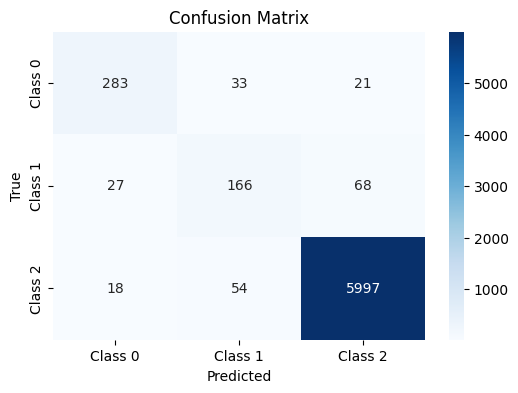

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       337
           1       0.66      0.64      0.65       261
           2       0.99      0.99      0.99      6069

    accuracy                           0.97      6667
   macro avg       0.83      0.82      0.83      6667
weighted avg       0.97      0.97      0.97      6667



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Function to evaluate confusion matrix, classification report, and plot confusion matrix as an image
def evaluate_and_plot_conf_matrix_class_report(model_1, data_loader, device):
    model_1.eval()  # Switch model to evaluation mode
    all_preds = []
    all_labels = []

    with torch.no_grad():  # No need to compute gradients during evaluation
        for batch in data_loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]  # Move the batch to the device
            outputs = model_1(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # Extract logits (predictions)
            preds = torch.argmax(logits, dim=-1)  # Get predicted class with the highest logit
            all_preds.extend(preds.cpu().numpy())  # Store the predictions
            all_labels.extend(labels.cpu().numpy())  # Store the true labels

    # Calculate confusion matrix and classification report
    conf_matrix = confusion_matrix(all_labels, all_preds)
    class_report = classification_report(all_labels, all_preds)

    # Plot confusion matrix as a heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1", "Class 2"], yticklabels=["Class 0", "Class 1", "Class 2"])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()  # This will display the confusion matrix as a heatmap

    # Print classification report
    print("Classification Report:")
    print(class_report)

# Evaluate and plot on the test data
evaluate_and_plot_conf_matrix_class_report(model_1, test_loader, device)

In [ ]:
# Save model
model_1.save_pretrained('./model')
tokenizer.save_pretrained('./model')

('./model/tokenizer_config.json',
 './model/special_tokens_map.json',
 './model/vocab.txt',
 './model/added_tokens.json')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# لحفظ النموذج على Google Drive
model_1.save_pretrained('/content/drive/MyDrive/model')
tokenizer.save_pretrained('/content/drive/MyDrive/model')


('/content/drive/MyDrive/model/tokenizer_config.json',
 '/content/drive/MyDrive/model/special_tokens_map.json',
 '/content/drive/MyDrive/model/vocab.txt',
 '/content/drive/MyDrive/model/added_tokens.json')

# - Task 2 -

 - ###  Product Category Clustering

### **Objective:** Simplify the dataset by clustering product categories into 4-6 meta-categories.

### **Task:** Create a model to group all reviews into 4-6 broader categories.


### Example suggestions:
- Ebook readers

- Batteries

- Accessories (keyboards, laptop stands, etc.)
- Non-electronics (Nespresso pods, pet carriers, etc.)


**Note: Analyze the dataset in depth to determine the most appropriate categories.**

In [14]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33332 entries, 0 to 33331
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  33332 non-null  object
 1   dateAdded           33332 non-null  object
 2   dateUpdated         33332 non-null  object
 3   name                33332 non-null  object
 4   asins               33332 non-null  object
 5   brand               33332 non-null  object
 6   categories          33332 non-null  object
 7   primaryCategories   33332 non-null  object
 8   imageURLs           33332 non-null  object
 9   keys                33332 non-null  object
 10  manufacturer        33332 non-null  object
 11  manufacturerNumber  33332 non-null  object
 12  reviews.date        33332 non-null  object
 13  reviews.dateSeen    33332 non-null  object
 14  reviews.rating      33332 non-null  int64 
 15  reviews.sourceURLs  33332 non-null  object
 16  reviews.text        33

In [20]:
unique_product_names = df_clean['name'].unique()
print(unique_product_names)

['AmazonBasics AAA Performance Alkaline Batteries (36 Count)'
 'AmazonBasics Nylon CD/DVD Binder (400 Capacity)' 'Amazon Echo ‚Äì White'
 'Amazon Echo Show - Black' 'Echo Spot Pair Kit (Black)'
 'Fire TV Stick Streaming Media Player Pair Kit'
 'AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary'
 'AmazonBasics Ventilated Adjustable Laptop Stand'
 'AmazonBasics Backpack for Laptops up to 17-inches'
 'AmazonBasics 11.6-Inch Laptop Sleeve'
 'AmazonBasics 15.6-Inch Laptop and Tablet Bag'
 'AmazonBasics External Hard Drive Case'
 'Expanding Accordion File Folder Plastic Portable Document Organizer Letter Size'
 'Cat Litter Box Covered Tray Kitten Extra Large Enclosed Hooded Hidden Toilet'
 'Amazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablets and Kindle eReaders'
 'Kindle PowerFast International Charging Kit (for accelerated charging in over 200 countries)'
 'AmazonBasics Silicone Hot Handle Cover/Holder - Red'
 'Amazon Kindle Charger P

In [22]:
unique_product_list = df_clean['name'].unique().tolist()
print(unique_product_list)


['AmazonBasics AAA Performance Alkaline Batteries (36 Count)', 'AmazonBasics Nylon CD/DVD Binder (400 Capacity)', 'Amazon Echo ‚Äì White', 'Amazon Echo Show - Black', 'Echo Spot Pair Kit (Black)', 'Fire TV Stick Streaming Media Player Pair Kit', 'AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary', 'AmazonBasics Ventilated Adjustable Laptop Stand', 'AmazonBasics Backpack for Laptops up to 17-inches', 'AmazonBasics 11.6-Inch Laptop Sleeve', 'AmazonBasics 15.6-Inch Laptop and Tablet Bag', 'AmazonBasics External Hard Drive Case', 'Expanding Accordion File Folder Plastic Portable Document Organizer Letter Size', 'Cat Litter Box Covered Tray Kitten Extra Large Enclosed Hooded Hidden Toilet', 'Amazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablets and Kindle eReaders', 'Kindle PowerFast International Charging Kit (for accelerated charging in over 200 countries)', 'AmazonBasics Silicone Hot Handle Cover/Holder - Red', 'Amazon Kindle Charger

In [23]:
print(f"Number of unique products: {len(unique_product_list)}")

Number of unique products: 79


In [15]:
df_V2 = df_clean.copy()

In [16]:
pip install sentence-transformers scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [17]:
pip install hf_xet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 MB 40.4 MB/s eta 0:00:00


In [18]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import pandas as pd

# Use the column that contains the category text
category_texts = df_V2['name'].fillna('unknown').astype(str).tolist()


# Load a transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(category_texts, show_progress_bar=True)

# Apply clustering
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
df_V2['cluster'] = kmeans.fit_predict(embeddings)

# Show some sample categories from each cluster
for i in range(k):
    print(f"\nCluster {i}")
    print(df_V2[df_V2['cluster'] == i]['name'].sample(20, random_state=1))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1042 [00:00<?, ?it/s]


Cluster 0
31434    Amazon Tap - Alexa-Enabled Portable Bluetooth ...
28914    Amazon Echo Show Alexa-enabled Bluetooth Speak...
29255    Amazon Echo Show Alexa-enabled Bluetooth Speak...
31490    Amazon Tap - Alexa-Enabled Portable Bluetooth ...
29315          Amazon - Echo Plus w/ Built-In Hub - Silver
28856    Amazon Echo Show Alexa-enabled Bluetooth Speak...
12094      AmazonBasics Ventilated Adjustable Laptop Stand
29022    Amazon Echo Show Alexa-enabled Bluetooth Speak...
12457    Amazon Tap Smart Assistant Alexaenabled (black...
28748    Amazon Echo Show Alexa-enabled Bluetooth Speak...
12455    Amazon Tap Smart Assistant Alexaenabled (black...
28836    Amazon Echo Show Alexa-enabled Bluetooth Speak...
12708    Amazon Tap Smart Assistant Alexaenabled (black...
31503    Amazon Tap - Alexa-Enabled Portable Bluetooth ...
12591    Amazon Tap Smart Assistant Alexaenabled (black...
29661          Amazon - Echo Plus w/ Built-In Hub - Silver
29211    Amazon Echo Show Alexa-enabled Bluet

In [24]:
cluster_names = {
    0: "Smart Devices & Alexa",
    1: "Kids' Tablets & Educational Devices",
    2: "Batteries & Accessories",
    3: "Tablets & E-readers",
    4: "Fire Tablets & Kindle Devices"
}

In [25]:
df_V2['meta_category'] = df_V2['cluster'].map(cluster_names)

In [26]:
print(df_V2['meta_category'].value_counts())

meta_category
Batteries & Accessories                12071
Tablets & E-readers                     6486
Fire Tablets & Kindle Devices           6307
Kids' Tablets & Educational Devices     6084
Smart Devices & Alexa                   2384
Name: count, dtype: int64


<ipython-input-27-dc29798ab7fe>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_V2, x='meta_category', order=df_V2['meta_category'].value_counts().index, palette='Set2')


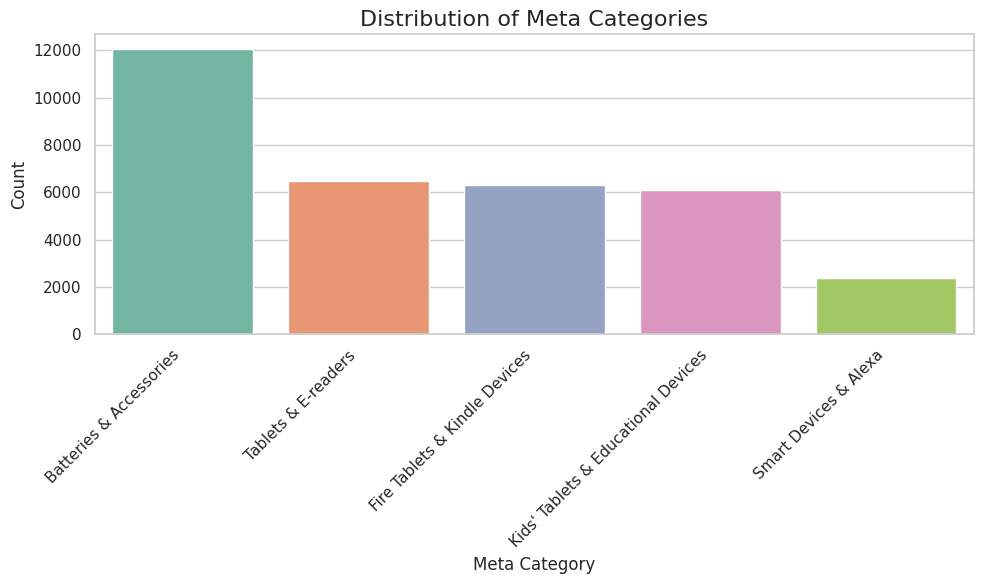

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot appearance
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Create a bar plot using the new 'meta_category'
sns.countplot(data=df_V2, x='meta_category', order=df_V2['meta_category'].value_counts().index, palette='Set2')

# Add title and axis labels
plt.title('Distribution of Meta Categories', fontsize=16)
plt.xlabel('Meta Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.show()

In [22]:
import joblib
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

# إنشاء النماذج
model = SentenceTransformer('all-MiniLM-L6-v2')
kmeans = KMeans(n_clusters=5, random_state=42)

# حفظ النماذج في ملف واحد
models = {'sentence_transformer': model, 'kmeans_model': kmeans}
joblib.dump(models, '/content/drive/MyDrive/models.pkl')

['/content/drive/MyDrive/models.pkl']

In [23]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import joblib

# إنشاء النماذج
model = SentenceTransformer('all-MiniLM-L6-v2')
kmeans = KMeans(n_clusters=5, random_state=42)

# حفظ نموذج SentenceTransformer باستخدام الطريقة المناسبة
model.save('/content/drive/MyDrive/sentence_transformer_model')

# حفظ نموذج KMeans باستخدام joblib
joblib.dump(kmeans, '/content/drive/MyDrive/kmeans_model.pkl')

['/content/drive/MyDrive/kmeans_model.pkl']

In [ ]:
import torch
from sentence_transformers import SentenceTransformer

# إنشاء النموذج
model = SentenceTransformer('all-MiniLM-L6-v2')

# حفظ النموذج باستخدام torch.save
torch.save(model.state_dict(), '/content/drive/MyDrive/sentence_transformer_model.pth')


# - Task 3 -
- ###  Summarize reviews using generative AI

##### **Objective**: Summarize reviews into articles that recommend the top products for each category.

#####**Task**: Create a model that generates a short article (like a blog post) for each product category. The output should include:


- Top 3 products and key differences between them.

- Top complaints for each of those products.

- Worst product in the category and why it should be avoided.

Consider using Pretrained Generative Models like T5, GPT-3, or BART for generating coherent and well-structured summaries. These models excel at tasks like summarization and text generation, and can be fine-tuned to produce high-quality outputs based on the extracted insights from reviews. You are encouraged to explore other Transformer-based models available on platforms like Hugging Face. Fine-tuning any of these pre-trained models on your specific dataset could further improve the relevance and quality of the generated summaries.

meta_category:

Batteries & Accessories                
Tablets & E-readers                     
Fire Tablets & Kindle Devices           
Kids' Tablets & Educational Devices     
Smart Devices & Alexa                   

In [28]:
import pandas as pd
from transformers import pipeline
import numpy as np
import torch

#### **Task Description: Building the Prompt for the Generative Model**

#####In this task, we developed a detailed and clear prompt that provides comprehensive information about the top three products in a specific category, including their complaints, along with the worst product based on negative reviews. The goal is to create a well-rounded input for generative models like GPT-2 or BART, which can then generate a short and informative article based on this input.

In [29]:
from transformers import pipeline

# تحميل النماذج مرة وحدة فقط
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# دالة تلخيص
def summarize_reviews(reviews):
    if not reviews:
        return "no major complaints reported."
    joined = " ".join(reviews[:3])
    if len(joined) > 1024:
        joined = joined[:1024]
    summary = summarizer(joined, max_length=50, min_length=25, do_sample=False)
    return summary[0]['summary_text']

# دالة استخراج الخصائص
def extract_features(reviews, classifier, candidate_labels):
    if not reviews:
        return "varied features"
    features = []
    for review in reviews:
        result = classifier(review, candidate_labels)
        features.append(result['labels'][0])
    return ", ".join(set(features))

# الدالة الرئيسية لإنشاء المقال
def generate_article(df, meta_category, candidate_labels, top_n=3):
    cat_df = df[df['meta_category'] == meta_category]
    pos_reviews = cat_df[cat_df['Sentiment Class'] == 'Positive']
    neg_reviews = cat_df[cat_df['Sentiment Class'] == 'Negative']

    top_products = pos_reviews['name'].value_counts().head(top_n).index.tolist()
    paragraph_parts = []

    for product in top_products:
        complaints = neg_reviews[neg_reviews['name'] == product]['reviews.text'].tolist()
        features = extract_features(complaints, classifier, candidate_labels)
        summary = summarize_reviews(complaints)
        paragraph_parts.append((product, features, summary))

    # أسوأ منتج حسب عدد المراجعات السلبية
    worst_product = neg_reviews['name'].value_counts().idxmax()
    worst_complaints = neg_reviews[neg_reviews['name'] == worst_product]['reviews.text'].tolist()
    worst_summary = summarize_reviews(worst_complaints)

    # بناء المقال
    article = ""
    for i, (product, features, summary) in enumerate(paragraph_parts):
        intro = "Among the top-rated" if i == 0 else "The" if i == 1 else "Another well-reviewed device,"
        article += (
            f"{intro} the **{product}** stands out for its {features}. "
            f"However, users have reported issues such as {summary.lower()} "
        )

    article += f"Overall, consumers are advised to avoid the **{worst_product}**, which has been frequently flagged for problems such as {worst_summary.lower()}."
    print(f"\n📘 Article for category: {meta_category}\n")
    print(article)
    print("\n" + "-"*100 + "\n")

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0


In [30]:
# قائمة الخصائص العامة
general_labels = ["performance", "battery", "screen", "speed", "durability", "price", "quality", "setup", "connectivity", "response", "voice recognition"]

# إنشاء مقالات لكل فئة:
generate_article(df_V2, 'Smart Devices & Alexa', general_labels)
generate_article(df_V2, "Kids' Tablets & Educational Devices", general_labels)
generate_article(df_V2, "Fire Tablets & Kindle Devices", general_labels)
generate_article(df_V2, "Tablets & E-readers", general_labels)
generate_article(df_V2, "Batteries & Accessories", general_labels, top_n=2)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



📘 Article for category: Smart Devices & Alexa

Among the top-rated the **Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7" Screen** stands out for its voice recognition, response, performance, screen, connectivity, price, setup. However, users have reported issues such as the plug adapter to turn on and off lights tv is useful and certainly worth having. youtube was one of the main features that i used. without youtube you'll be better off buying the $40 echo dot instead. The the **Amazon - Echo Plus w/ Built-In Hub - Silver** stands out for its voice recognition, response, performance, connectivity, quality. However, users have reported issues such as this does not give great answers and the connection is not that great. waste of money, ask alexa a question and you are lucky if you get an answer instead of i'm not sure. Another well-reviewed device, the **Amazon Tap Smart Assistant Alexaenabled (black) Brand New** stands out for its voice recognition, price, response, performa

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# تحميل النموذج
model = AutoModelForSeq2SeqLM.from_pretrained('facebook/bart-large-cnn')

# تحديد مكان الحفظ
model_save_path = '/content/drive/My Drive/Last_model_folder/'

# حفظ النموذج والـtokenizer
model.save_pretrained(model_save_path)
tokenizer = AutoTokenizer.from_pretrained('facebook/bart-large-cnn')
tokenizer.save_pretrained(model_save_path)

/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3353: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


('/content/drive/My Drive/Last_model_folder/tokenizer_config.json',
 '/content/drive/My Drive/Last_model_folder/special_tokens_map.json',
 '/content/drive/My Drive/Last_model_folder/vocab.json',
 '/content/drive/My Drive/Last_model_folder/merges.txt',
 '/content/drive/My Drive/Last_model_folder/added_tokens.json',
 '/content/drive/My Drive/Last_model_folder/tokenizer.json')